In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report)
import os

## train

In [ ]:
np.random.seed(42)

selected_columns = ['Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min',  'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 
      'Down/Up Ratio',
       'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
        'Subflow Fwd Bytes', 'Subflow Bwd Packets',
       'Subflow Bwd Bytes', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes',
       'Fwd Act Data Packets', 'Fwd Seg Size Min', 'Active Mean', 'Active Std',
       'Active Max', 'Active Min', 'Label']

def load_data(file_path):
    data = pd.read_csv(file_path)
    data = data[selected_columns] 
    print(f"Original data shape: {data.shape}")
    
    X = data.drop(columns=['Label'])
    y = data['Label']
    
    # if y.dtype == 'object':
    #     le = LabelEncoder()
    #     y = le.fit_transform(y)
    #     joblib.dump(le, 'config/label_encoder.pkl')  # Lưu bộ mã hóa để dùng sau
    #     print("Label classes:", le.classes_)

    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Label classes:", le.classes_) # ['BENIGN' 'Group1' 'Group2' 'Syn']
    
    return X, y

X, y = load_data("csv/cicddos_2019_4_labels.csv")

Original data shape: (20000, 57)
Label classes: ['BENIGN' 'Group1' 'Group2' 'Syn']


In [ ]:
def preprocess_features(X, config_path="models/tabnet"):
    os.makedirs(config_path, exist_ok=True)
    
    X.fillna(X.median(), inplace=True)
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(0, inplace=True)
    
    scaler_path = f"{config_path}/scaler.pkl"
    if os.path.exists(scaler_path):
        print("Loading existing scaler...")
        scaler = joblib.load(scaler_path)
        X_scaled = scaler.transform(X)
    else:
        print("Fitting new scaler...")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        joblib.dump(scaler, scaler_path)
    
    selector_path = f"{config_path}/selector.pkl"
    if os.path.exists(selector_path):
        print("Loading existing feature selector...")
        selector = joblib.load(selector_path)
        X_selected = selector.transform(X_scaled)
    else:
        print("Fitting new feature selector...")
        var_threshold = VarianceThreshold(threshold=0.01)
        X_high_var = var_threshold.fit_transform(X_scaled)
        
        selector = SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=42),
            threshold="median"
        )
        selector.fit(X_high_var, y)
        X_selected = selector.transform(X_high_var)
        joblib.dump(selector, selector_path)
    
    print(f"Shape after preprocessing: {X_selected.shape}")
    return X_selected

X_processed = preprocess_features(X)

Loading existing scaler...
Loading existing feature selector...
Shape after preprocessing: (20000, 28)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_processed, y, test_size=0.1, random_state=42, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Train: (18000, 28), Valid: (1000, 28), Test: (1000, 28)


f:\NCKH\code\train_model_2\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.42257 | valid_accuracy: 0.426   |  0:00:00s
epoch 10 | loss: 0.28145 | valid_accuracy: 0.929   |  0:00:07s
epoch 20 | loss: 0.15625 | valid_accuracy: 0.96    |  0:00:14s
epoch 30 | loss: 0.12711 | valid_accuracy: 0.977   |  0:00:21s
epoch 40 | loss: 0.09839 | valid_accuracy: 0.977   |  0:00:27s
epoch 50 | loss: 0.08848 | valid_accuracy: 0.979   |  0:00:34s
epoch 60 | loss: 0.08175 | valid_accuracy: 0.986   |  0:00:41s
epoch 70 | loss: 0.07643 | valid_accuracy: 0.987   |  0:00:48s

Early stopping occurred at epoch 76 with best_epoch = 56 and best_valid_accuracy = 0.987


f:\NCKH\code\train_model_2\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at models/tabnet/tabnet.zip
{'loss': [1.4225690364837646, 1.1882645785808563, 1.0097248628735542, 0.8376946747303009, 0.6915870010852814, 0.5729022473096848, 0.45516540110111237, 0.3861459381878376, 0.34846707805991173, 0.324301864951849, 0.28145409747958183, 0.24997383542358878, 0.23118593730032444, 0.2107415907084942, 0.20258300937712193, 0.18702449835836887, 0.1876711044460535, 0.17549406550824642, 0.1665609609335661, 0.16464566439390182, 0.15625147335231304, 0.15086962282657623, 0.14592287316918373, 0.15020448621362448, 0.1420618463307619, 0.1424700329080224, 0.13559808023273945, 0.14380559138953686, 0.12571467738598585, 0.12473988346755505, 0.12711461074650288, 0.11512737814337015, 0.10921792685985565, 0.10969223733991385, 0.10354608856141567, 0.10228803474456072, 0.10267299879342318, 0.10217548720538616, 0.11156106553971767, 0.11358092166483402, 0.09838558081537485, 0.0990547826513648, 0.09523940272629261, 0.09720657300204039, 0.09803597256541252, 0.10303

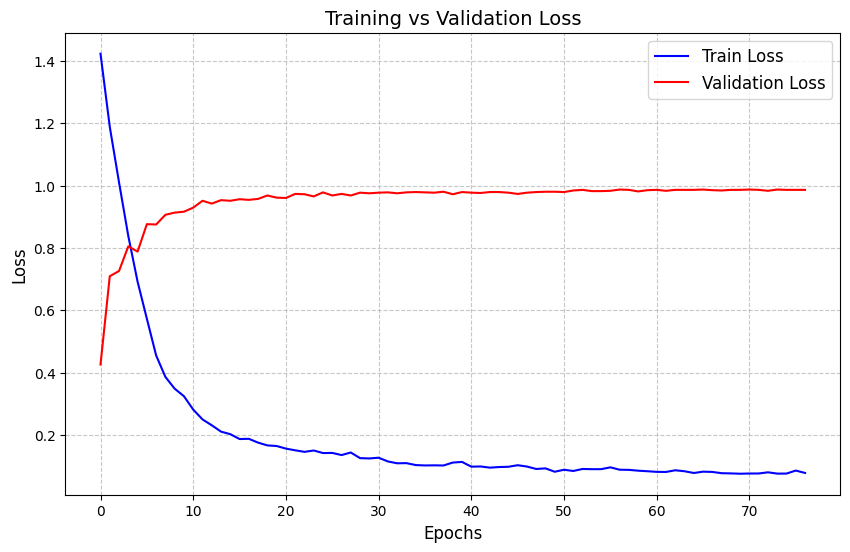

In [ ]:
def train_tabnet(X_train, y_train, X_valid, y_valid):
    model = TabNetClassifier(
        n_d=4,                   
        n_a=4,                 
        n_steps=2,              
        gamma=1.3,
        lambda_sparse=1e-2,      
        optimizer_params={"lr": 1e-2}, 
        verbose=10,
        seed=42
    )
    
    model.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_valid, y_valid)],
        eval_name=["valid"],
        eval_metric=["accuracy"],
        max_epochs=200,
        patience=20,
        batch_size=2048
    )
    
    model.save_model("models/tabnet/tabnet")
    plt.figure(figsize=(10, 6))

    print(model.history)
    
    train_loss = model.history['loss']
    valid_loss = model.history['valid_accuracy']  # TabNet dùng 'val_0_loss' thay vì 'valid_loss'

    
    plt.plot(train_loss, label='Train Loss', color='blue')
    plt.plot(valid_loss, label='Validation Loss', color='red')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training vs Validation Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    # plt.savefig("loss_curve.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    return model

model = train_tabnet(X_train, y_train, X_valid, y_valid)

Accuracy: 0.9840
Precision (macro): 0.9840
Recall (macro): 0.9840
F1 (macro): 0.9840

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       250
           1       0.98      0.98      0.98       250
           2       0.98      0.98      0.98       250
           3       0.98      1.00      0.99       250

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



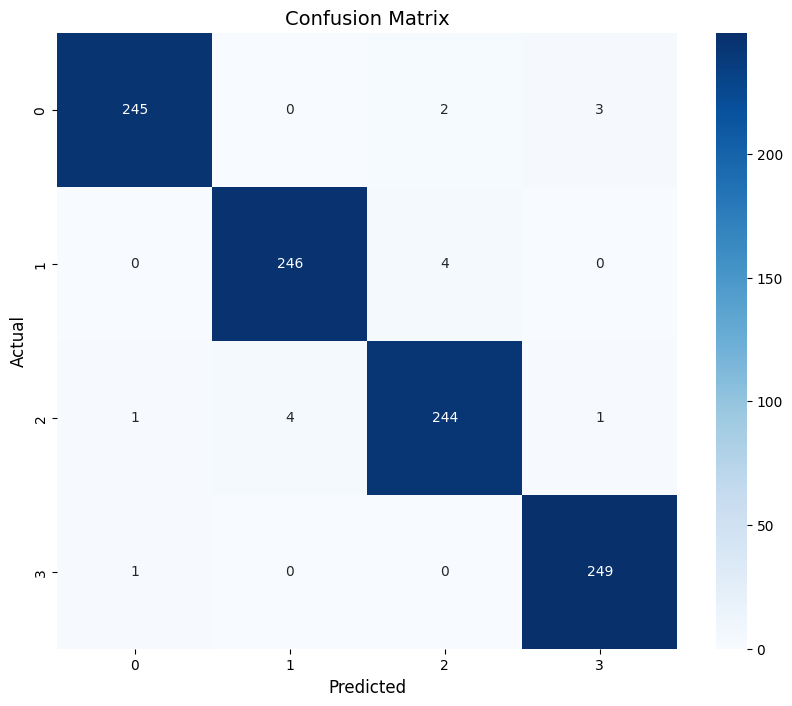

In [ ]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.title("Confusion Matrix", fontsize=14)
    plt.savefig("confusion_matrix.png", bbox_inches='tight', dpi=300)
    plt.show()

evaluate(model, X_test, y_test)

## test

In [5]:
selected_columns = ['Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min',  'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 
      'Down/Up Ratio',
       'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
        'Subflow Fwd Bytes', 'Subflow Bwd Packets',
       'Subflow Bwd Bytes', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes',
       'Fwd Act Data Packets', 'Fwd Seg Size Min', 'Active Mean', 'Active Std',
       'Active Max', 'Active Min', 'Label']

model = TabNetClassifier()
model.load_model("temp/models/tabnet/tabnet.zip")
scaler = joblib.load("temp/models/tabnet/scaler.pkl")
selector = joblib.load("temp/models/tabnet/selector.pkl")

def static(csv_path):
    stat = {}
    labels = ['BENIGN', 'Group1', 'Group2', 'Syn']

    for chunk in pd.read_csv(csv_path, chunksize=1):
        row = chunk[selected_columns].copy()
        
        X = row.drop(columns=['Label'])
        X.fillna(X.median(), inplace=True)

        X_scaled = scaler.transform(X)
        X_selected = selector.transform(X_scaled)
        y_pred = model.predict(X_selected)
        # print(f"{y_pred[0]}")
        
        if labels[int(y_pred[0])] not in stat:
            stat[labels[int(y_pred[0])]] = 0
        else:
            stat[labels[int(y_pred[0])]] += 1

    print(stat)


f:\NCKH\code\DN\IDS-RESNET-50-System\train_model\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [ ]:
static('temp/test/benign.csv')
static('temp/test/syn.csv')
static('temp/test/udp.csv')

# static('test/syn_2.csv')